# CSCI218 Group Assignment (FT17)

Name: Muhammad Zafiq Bin Abdul Rahman

Student No.: 8496481

---

Name: Agellon Raven Nixzon Pasco

Student No.: 9069902

---

Name: Nur Syaziah Bte Mohamad Rhazali

Student No.: 8769060

---

Name: Brandon Au Yong Kah Keat

Student No.: 8761371

---

Name: Rong Xiang Ng

Student No.: 9089287

---

Name: Shawn Kiswoto

Student No.: 8750580

---

# **1. Import Libraries**

In [ ]:
!pip install ucimlrepo
!pip install lightgbm

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings

# Scikit-learn: Model Selection & Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Scikit-learn: Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# Scikit-learn: Evaluation Metrics
from sklearn.metrics import (accuracy_score, classification_report,
                             ConfusionMatrixDisplay, confusion_matrix,
                             precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve)

# Imbalanced-learn: Resampling
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

# Boosting Models
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')

# **2. Load Dataset**

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
bank_marketing = fetch_ucirepo(id=222)

# data (as pandas dataframes)
X = bank_marketing.data.features
y = bank_marketing.data.targets

# metadata
print(bank_marketing.metadata)

# variable information
print(bank_marketing.variables)

{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

# **3. Preprocessing Data and Data Exploration**

We will combine the x and y columns into a singular dataframe, so we may do Data pre-processing and exploration on the dataset before our train-test split.

We can make use of Principle Component Analysis to see how far apart the data is from each other.

In [ ]:
# Combine X + y
df = X.copy()
df["y"] = y.iloc[:, 0]   # target column

print("Dataset Original Size:", df.shape)

# Clean string columns
obj_cols = df.select_dtypes(include=["object"]).columns

for col in obj_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('"', "", regex=False)
        .str.strip()
        .str.lower()
    )

# Treat "unknown" as missing
df.replace("unknown", np.nan, inplace=True)

# Convert target to binary
if df["y"].dtype == "object":
    df["y"] = df["y"].map({"yes": 1, "no": 0})

df["y"] = df["y"].astype("int8")

# Identify categorical columns (exclude target)
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
cat_cols = [c for c in cat_cols if c != "y"]

# One-Hot Encode categoricals
if len(cat_cols) > 0:
    df = pd.get_dummies(
        df,
        columns=cat_cols,
        drop_first=True,
        dummy_na=True
    )

# Remove duplicate columns (safety check)
df = df.loc[:, ~df.columns.duplicated()].copy()

# Convert bool to int (model-friendly)
bool_cols = df.select_dtypes(include=["bool"]).columns
df[bool_cols] = df[bool_cols].astype("int8")

# Impute remaining numeric NaNs
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove("y")

for col in num_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

# Final verification
print(f"\nFinal shape: {df.shape}")
print("\nTarget distribution:")
print(df["y"].value_counts())
print("\nAny duplicated columns?", df.columns.duplicated().any())

display(df.head())


Dataset Original Size: (45211, 17)

Final shape: (45211, 49)

Target distribution:
y
0    39922
1     5289
Name: count, dtype: int64

Any duplicated columns? False


,age,balance,day_of_week,duration,campaign,pdays,previous,y,job_blue-collar,job_entrepreneur,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,month_nan,poutcome_nan,poutcome_other,poutcome_success
0,58,2143,5,261,1,-1,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
1,44,29,5,151,1,-1,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
2,33,2,5,76,1,-1,0,0,0,1,...,0,0,1,0,0,0,0,1,0,0
3,47,1506,5,92,1,-1,0,0,1,0,...,0,0,1,0,0,0,0,1,0,0
4,33,1,5,198,1,-1,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0


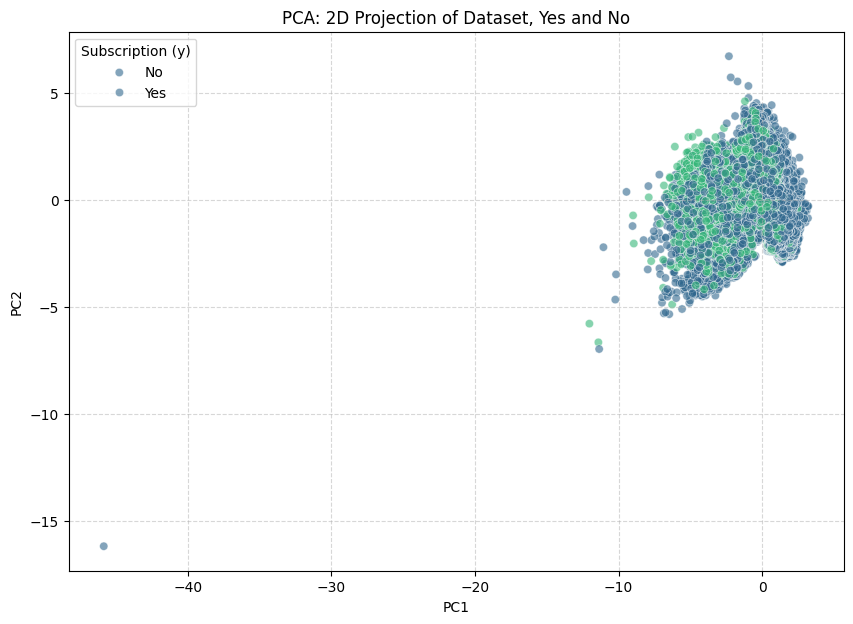

In [ ]:
# Principle component Analysis ( Remove If not needed/ Useless ) We could also convert this to 3D if it is highly advantages.- Rex
X_pca = df.drop(columns=['y'])

# Initialize the StandardScaler
scaler_pca = StandardScaler()

# Transform the Features into 2 Dims
X_scaled = scaler_pca.fit_transform(X_pca)
pca = PCA(n_components=2)
X_pca_2d = pca.fit_transform(X_scaled)

# Get the explained variance ratio
variance_ratio = pca.explained_variance_ratio_
# PCA DF
pca_df = pd.DataFrame(data=X_pca_2d, columns=['PC1', 'PC2'])
pca_df['y'] = df['y'].values
# Create the scatter plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='y',
    alpha=0.6,
    palette='viridis'
)

plt.title('PCA: 2D Projection of Dataset, Yes and No')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Subscription (y)', labels=['No', 'Yes'])
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [ ]:
print(variance_ratio)

[0.07224784 0.06362569]


Sampled and scaled feature matrix shape: (5000, 48)
Target vector shape: (5000,)
Shape of transformed t-SNE data: (5000, 2)


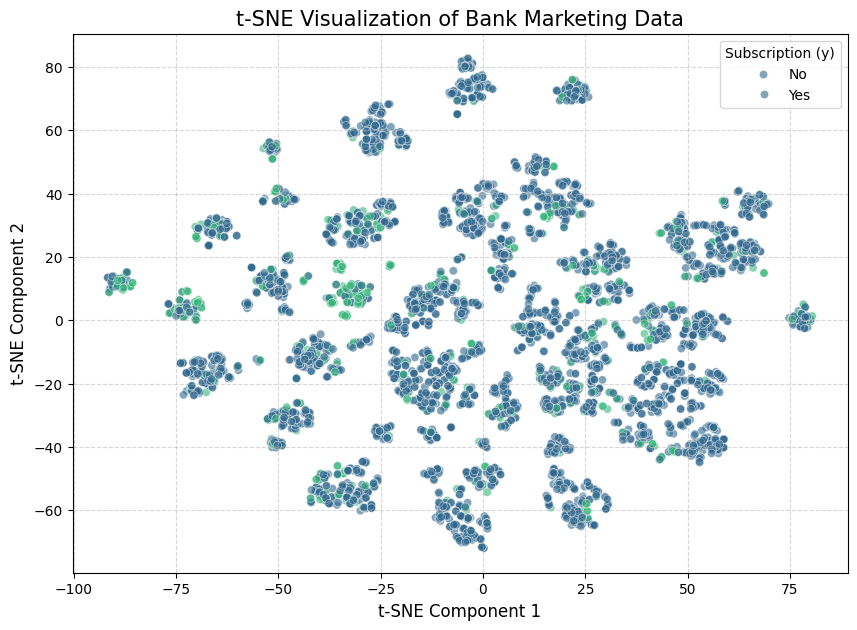

In [ ]:

df_sample = df.sample(n=5000, random_state=42)

# 2. Separate into features and target
X_sample = df_sample.drop(columns=['y'])
y_sample = df_sample['y']

# 3. Initialize and apply StandardScaler
scaler_tsne = StandardScaler()
X_sample_scaled = scaler_tsne.fit_transform(X_sample)

# 4. Verify the shape
print(f"Sampled and scaled feature matrix shape: {X_sample_scaled.shape}")
print(f"Target vector shape: {y_sample.shape}")

# Initialize t-SNE with 2 components and fixed random state
tsne = TSNE(n_components=2, perplexity=30, random_state=42)

# Fit and transform the scaled sample data
X_tsne_2d = tsne.fit_transform(X_sample_scaled)

print(f"Shape of transformed t-SNE data: {X_tsne_2d.shape}")
tsne_df = pd.DataFrame(data=X_tsne_2d, columns=['TSNE1', 'TSNE2'])
tsne_df['y'] = y_sample.values


plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=tsne_df,
    x='TSNE1',
    y='TSNE2',
    hue='y',
    palette='viridis',
    alpha=0.6
)


plt.title('t-SNE Visualization of Bank Marketing Data', fontsize=15)
plt.xlabel('t-SNE Component 1', fontsize=12)
plt.ylabel('t-SNE Component 2', fontsize=12)
plt.legend(title='Subscription (y)', labels=['No', 'Yes'])
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### **Conclusion:**

As seen in the above class counts, the classes (Yes and No) are heavily imbalanced in favour of the No class.

The 2-Dims PCA and t-SNE Both classes are also heavily overlapped with one another and, a Low Variance Ratio suggests that Features are very independent of each other.

# 3.5 Feature Engineering

In this section, we create new features to improve the model's predictive power. First, we check whether the client was contacted in a previous campaign by looking at the pdays column, where a value of -1 means no prior contact. We then apply a log transformation to the balance column to handle its heavy skewness, clipping negative values to zero before transforming. Next, we create a binary feature indicating whether the previous campaign outcome was a success. We also add age-based flags to capture that clients under 30 and those over 60 tend to have higher subscription rates. A high_campaign flag marks clients who were contacted more than 5 times in the current campaign, which typically signals rejection. We identify recently contacted clients as those reached within the last 30 days. Finally, we create an interaction feature that multiplies the log-transformed balance with previous campaign success, capturing the stronger signal when a high-balance client also had a successful prior outcome.

In [ ]:
# Was client contacted in a previous campaign?
df["was_contacted_before"] = (df["pdays"] != -1).astype(int)

# Log-transform balance (heavily skewed column)
df["log_balance"] = np.log1p(df["balance"].clip(lower=0))

# Did previous campaign succeed?
if "poutcome" in df.columns:
    df["prev_success"] = (df["poutcome"] == "success").astype(int)
elif "poutcome_success" in df.columns:
    df["prev_success"] = df["poutcome_success"]
else:
    print("poutcome not found — skipping prev_success")

# Age bins (young and retired clients subscribe more)
df["is_young"] = (df["age"] < 30).astype(int)
df["is_retired_age"] = (df["age"] > 60).astype(int)

# Contact intensity: high campaign count usually means rejection
df["high_campaign"] = (df["campaign"] > 5).astype(int)

# Balance × previous outcome interaction
if "poutcome_success" in df.columns:
    df["balance_x_prevsuccess"] = df["log_balance"] * df["poutcome_success"]

# Pdays: contacted recently vs never
df["recently_contacted"] = ((df["pdays"] > 0) & (df["pdays"] < 30)).astype(int)


## **4. Data Splitting & Resampling**
We split the data into Training (70%) and Testing (30%) sets. Categorical columns such as job, marital, education, contact, month, and poutcome are one-hot encoded so the models can learn from them. We also apply **SMOTE (Synthetic Minority Oversampling Technique)** inside the pipeline to handle the 7.5:1 class imbalance  instead of deleting majority class samples, SMOTE synthetically generates new minority ("yes") samples during training only, preserving all original data and preventing data leakage across cross-validation folds.

In [ ]:
# One-hot encode categoricals + drop duration
cat_cols_model = ["job","marital","education","contact","month","poutcome"]

X_model = df.drop(columns=["y","duration"], errors="ignore")
X_model = pd.get_dummies(
    X_model,
    columns=[c for c in cat_cols_model if c in X_model.columns],
    drop_first=True
)
# Convert any bool columns to int
X_model = X_model.astype(
    {c: int for c in X_model.select_dtypes("bool").columns}
)
y_model = df["y"]

# 70/30 split
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model,
    test_size=0.3, random_state=42, stratify=y_model
)

# Class imbalance ratio
neg, pos   = np.bincount(y_train)
scale_full = neg / pos
scale_soft = scale_full / 2

print(f"Total samples          : {df.shape[0]}")
print(f"Features               : {X_train.shape[1]}")
print(f"Training samples (70%) : {X_train.shape[0]}")
print(f"Test samples     (30%) : {X_test.shape[0]}")
print(f"Class ratio            : {scale_full:.1f}:1")

Total samples          : 45211
Features               : 55
Training samples (70%) : 31647
Test samples     (30%) : 13564
Class ratio            : 7.5:1


## **5. Model Training, Test and Selection**
We train and compare seven classification algorithms: KNN, Logistic Regression, Naive Bayes, Random Forest, XGBoost, LightGBM, and SVM. Since the dataset is heavily imbalanced at 7.5:1, **SMOTETomek** is applied within each pipeline as the sole imbalance strategy which is combining SMOTE oversampling of the minority class with Tomek Links cleanup to remove noisy boundary samples, resulting in cleaner decision boundaries than SMOTE alone. Models such as Random Forest and Logistic Regression additionally use `class_weight="balanced"` for internal cost-sensitive learning, while XGBoost and LightGBM rely on SMOTETomek alone to avoid double-compensating for the imbalance. Performance is measured using 5-fold Stratified Cross-Validation to ensure the class ratio is maintained across all folds. The final model is selected based on F1 score rather than accuracy, as accuracy alone is misleading on imbalanced data. Threshold tuning is also applied to each model to find the optimal decision cutoff beyond the default 0.5.

----

In [ ]:
candidate_models = {
    "KNN": KNeighborsClassifier(
        n_neighbors=11,
        weights="distance",
        metric="manhattan"),

    "Logistic Regression": LogisticRegression(
        C=0.05,
        class_weight="balanced",
        solver="saga",
        penalty="l2",
        max_iter=1000),

    "Naive Bayes": GaussianNB(var_smoothing=1e-8),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=3,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1),

    "XGBoost": xgb.XGBClassifier(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_soft,
        min_child_weight=3,
        gamma=0.1,
        reg_alpha=0.05,
        reg_lambda=0.5,
        tree_method="hist",
        eval_metric="logloss",
        random_state=42),

    "LightGBM": lgb.LGBMClassifier(
        n_estimators=800,
        learning_rate=0.01,
        num_leaves=63,
        max_depth=9,
        min_child_samples=15,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        scale_pos_weight=scale_soft,
        reg_alpha=0.05,
        reg_lambda=0.1,
        random_state=42,
        verbose=-1),

    "SVM": CalibratedClassifierCV(
        LinearSVC(
            C=0.05,
            class_weight="balanced",
            max_iter=2000,
            random_state=42),
        cv=3),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"accuracy": "accuracy", "precision": "precision",
           "recall": "recall", "f1": "f1", "roc_auc": "roc_auc"}

rows  = []
pipes = {}

for name, model in candidate_models.items():
    print(f"  Training {name}...")

    pipe = ImbPipeline([
        ("scaler",   StandardScaler()),
        ("resample", SMOTE(k_neighbors=5, sampling_strategy=0.4, random_state=42)),
        ("model",    model)
    ])
    pipes[name] = pipe

    out = cross_validate(
        pipe, X_train, y_train,
        cv=cv, scoring=scoring,
        n_jobs=-1, return_estimator=True
    )

    row = {"Model": name, "fit_time_mean": np.mean(out["fit_time"])}
    for k, v in out.items():
        if k.startswith("test_"):
            m = k.replace("test_", "")
            row[f"{m}_mean"] = np.mean(v)
            row[f"{m}_std"]  = np.std(v)
    rows.append(row)

# Test set evaluation for All models
test_f1s = {}
test_rows = []

for name, pipe in pipes.items():
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]

    best_f1, best_thresh = 0, 0.5
    for thresh in np.arange(0.20, 0.71, 0.005):
        f1 = f1_score(y_test, (proba >= thresh).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_thresh = f1, thresh

    preds = (proba >= best_thresh).astype(int)
    test_f1s[name] = {"tuned_f1": best_f1, "threshold": best_thresh}

    test_rows.append({
        "Model":     name,
        "Accuracy":  accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall":    recall_score(y_test, preds, zero_division=0),
        "Test F1":   best_f1,
        "AUC":       roc_auc_score(y_test, proba),
        "Threshold": best_thresh,
    })

# CV results table
cv_results = (
    pd.DataFrame(rows)
    .sort_values("f1_mean", ascending=False)
    .reset_index(drop=True)
)

print("\nCross-Validation Results (5-Fold)")
display(
    cv_results.rename(columns={
        "fit_time_mean":  "Training Time (s)",
        "accuracy_mean":  "Accuracy",
        "precision_mean": "Precision",
        "recall_mean":    "Recall",
        "f1_mean":        "F1",
        "roc_auc_mean":   "AUC",
    }).set_index("Model")[[
        "Training Time (s)", "Accuracy", "Precision", "Recall", "F1", "AUC"
    ]]
)

# Test set results table (all models)
test_results_df = (
    pd.DataFrame(test_rows)
    .sort_values("Test F1", ascending=False)
    .reset_index(drop=True)
    .set_index("Model")
)

print("\nTest Set Performance (All Models)")
display(test_results_df)

# Best model for downstream cells
best_model_name = max(test_f1s, key=lambda x: test_f1s[x]["tuned_f1"])
best_threshold  = test_f1s[best_model_name]["threshold"]
THRESHOLD       = best_threshold

print(f"\nBest Model : {best_model_name}")
print(f"Test F1    : {test_f1s[best_model_name]['tuned_f1']:.4f}")
print(f"Threshold  : {best_threshold:.3f}")

  Training KNN...
  Training Logistic Regression...
  Training Naive Bayes...
  Training Random Forest...
  Training XGBoost...
  Training LightGBM...
  Training SVM...

Cross-Validation Results (5-Fold)


,Training Time (s),Accuracy,Precision,Recall,F1,AUC
Model,,,,,,
LightGBM,12.699529,0.859608,0.420260,0.528084,0.467983,0.794267
XGBoost,8.444327,0.851171,0.400197,0.546185,0.461890,0.793376
SVM,1.134480,0.877397,0.470860,0.392485,0.427930,0.769754
Random Forest,19.322535,0.836256,0.359906,0.514846,0.423518,0.777647
Naive Bayes,0.221890,0.857490,0.395841,0.414359,0.404619,0.740059
KNN,0.300433,0.850381,0.372143,0.406259,0.388176,0.728701
Logistic Regression,13.333264,0.754479,0.268571,0.637489,0.377872,0.770617



Test Set Performance (All Models)


,Accuracy,Precision,Recall,Test F1,AUC,Threshold
Model,,,,,,
LightGBM,0.879608,0.486027,0.504096,0.494896,0.796887,0.555
XGBoost,0.876733,0.474956,0.507876,0.490865,0.797741,0.560
Logistic Regression,0.871646,0.451815,0.454946,0.453375,0.774192,0.650
SVM,0.880345,0.486842,0.419660,0.450761,0.773540,0.485
Random Forest,0.860218,0.417158,0.490233,0.450753,0.775949,0.535
Naive Bayes,0.861693,0.409631,0.412728,0.411174,0.742857,0.435
KNN,0.838101,0.353676,0.463768,0.401309,0.736427,0.435



Best Model : LightGBM
Test F1    : 0.4949
Threshold  : 0.555


## **6. Business Insights: Economic & Demographic Deep Dive**
After identifying the best model, we analyze the underlying data to understand which factors (like interest rates and marital status) are most strongly associated with a 'Yes' response.

Using tuned threshold: 0.500


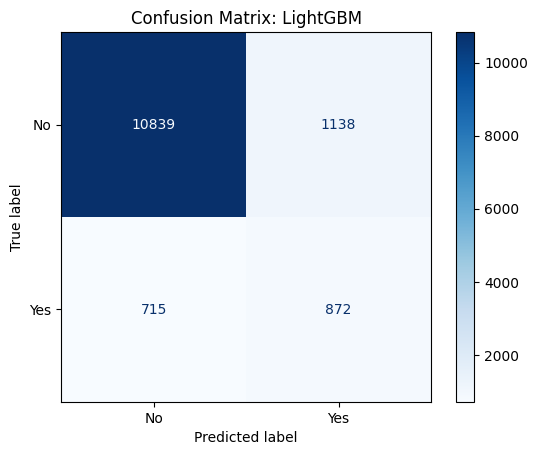


--- Confusion Matrix Counts for LightGBM ---
True Positives (TP): 872
True Negatives (TN): 10839
False Positives (FP): 1138
False Negatives (FN): 715

--- Classification Report for LightGBM ---
              precision    recall  f1-score   support

          No       0.94      0.90      0.92     11977
         Yes       0.43      0.55      0.48      1587

    accuracy                           0.86     13564
   macro avg       0.69      0.73      0.70     13564
weighted avg       0.88      0.86      0.87     13564



In [ ]:
if best_model_name in pipes:  # sklearn pipeline models
    pipe = pipes[best_model_name]

    if hasattr(pipe, "predict_proba"):
        y_prob_best = pipe.predict_proba(X_test)[:, 1]
        y_pred_best = (y_prob_best >= THRESHOLD).astype(int)
    else:
        y_pred_best = pipe.predict(X_test)

print(f"Using tuned threshold: {THRESHOLD:.3f}")

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_best)
TN, FP, FN, TP = conf_matrix.ravel()

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=["No", "Yes"])
disp.plot(values_format="d", cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()

print(f"\n--- Confusion Matrix Counts for {best_model_name} ---")
print(f"True Positives (TP): {TP}")
print(f"True Negatives (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")

print(f"\n--- Classification Report for {best_model_name} ---")
print(classification_report(y_test, y_pred_best, target_names=["No", "Yes"]))

In [ ]:
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_best}, index=X_test.index)

category_metrics = {}
education_cols = [col for col in X_test.columns if col.startswith('education_')]

for category in education_cols:
    mask = X_test[category] == 1
    cat_actual = results_df.loc[mask, 'Actual']
    cat_pred = results_df.loc[mask, 'Predicted']

    if len(cat_actual) > 0:
        precision = precision_score(cat_actual, cat_pred, zero_division=0)
        recall = recall_score(cat_actual, cat_pred, zero_division=0)
        f1 = f1_score(cat_actual, cat_pred, zero_division=0)

        category_label = category.replace('education_', '')
        category_metrics[category_label] = {
            'Precision': precision,
            'Recall': recall,
            'F1 Score': f1
        }

print(f"\n--- Performance by Education Category (Model: {best_model_name}) ---\n")
if not category_metrics:
    print("No education categories found or insufficient data for analysis.")
else:
    for cat, metrics in category_metrics.items():
        print(f"Category: {cat}")
        print(f"  Precision: {metrics['Precision']:.4f} | Recall: {metrics['Recall']:.4f} | F1: {metrics['F1 Score']:.4f}\n")


--- Performance by Education Category (Model: LightGBM) ---

Category: primary
  Precision: 0.4205 | Recall: 0.4181 | F1: 0.4193

Category: secondary
  Precision: 0.4473 | Recall: 0.5000 | F1: 0.4722

Category: tertiary
  Precision: 0.4254 | Recall: 0.6343 | F1: 0.5093



In [ ]:
# -------- Duration --------
df["duration_bin"] = pd.cut(df["duration"], bins=6)

duration_acceptance = (
    df.groupby("duration_bin")["y"]
      .mean()
      .reset_index(name="mean")
)

# -------- Campaign --------
df["campaign_bin"] = pd.cut(df["campaign"], bins=6)

campaign_acceptance = (
    df.groupby("campaign_bin")["y"]
      .mean()
      .reset_index(name="mean")
)

# -------- Balance --------
df["balance_bin"] = pd.cut(df["balance"], bins=6)

balance_acceptance = (
    df.groupby("balance_bin")["y"]
      .mean()
      .reset_index(name="mean")
)

display(duration_acceptance.head())
display(campaign_acceptance.head())
display(balance_acceptance.head())

,duration_bin,mean
0,"(-4.918, 819.667]",0.097723
1,"(819.667, 1639.333]",0.576302
2,"(1639.333, 2459.0]",0.574803
3,"(2459.0, 3278.667]",0.666667
4,"(3278.667, 4098.333]",0.166667


,campaign_bin,mean
0,"(0.938, 11.333]",0.118916
1,"(11.333, 21.667]",0.035623
2,"(21.667, 32.0]",0.017544
3,"(32.0, 42.333]",0.000000
4,"(42.333, 52.667]",0.000000


,balance_bin,mean
0,"(-8129.146, 10338.667]",0.116264
1,"(10338.667, 28696.333]",0.157447
2,"(28696.333, 47054.0]",0.152174
3,"(47054.0, 65411.667]",0.181818
4,"(65411.667, 83769.333]",0.400000


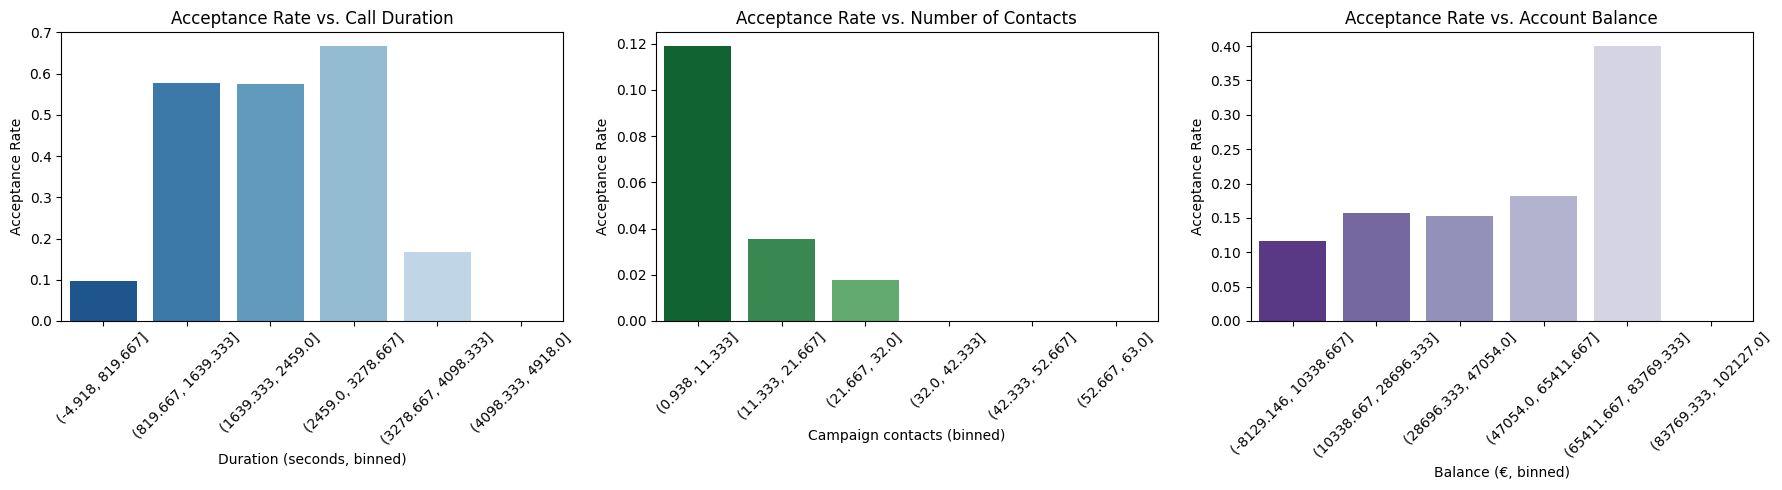

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Duration
sns.barplot(
    ax=axes[0],
    x=duration_acceptance["duration_bin"].astype(str),
    y=duration_acceptance["mean"],
    palette="Blues_r"
)
axes[0].set_title("Acceptance Rate vs. Call Duration")
axes[0].set_xlabel("Duration (seconds, binned)")
axes[0].set_ylabel("Acceptance Rate")
axes[0].tick_params(axis="x", rotation=45)

# Campaign
sns.barplot(
    ax=axes[1],
    x=campaign_acceptance["campaign_bin"].astype(str),
    y=campaign_acceptance["mean"],
    palette="Greens_r"
)
axes[1].set_title("Acceptance Rate vs. Number of Contacts")
axes[1].set_xlabel("Campaign contacts (binned)")
axes[1].set_ylabel("Acceptance Rate")
axes[1].tick_params(axis="x", rotation=45)

# Balance
sns.barplot(
    ax=axes[2],
    x=balance_acceptance["balance_bin"].astype(str),
    y=balance_acceptance["mean"],
    palette="Purples_r"
)
axes[2].set_title("Acceptance Rate vs. Account Balance")
axes[2].set_xlabel("Balance (€, binned)")
axes[2].set_ylabel("Acceptance Rate")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

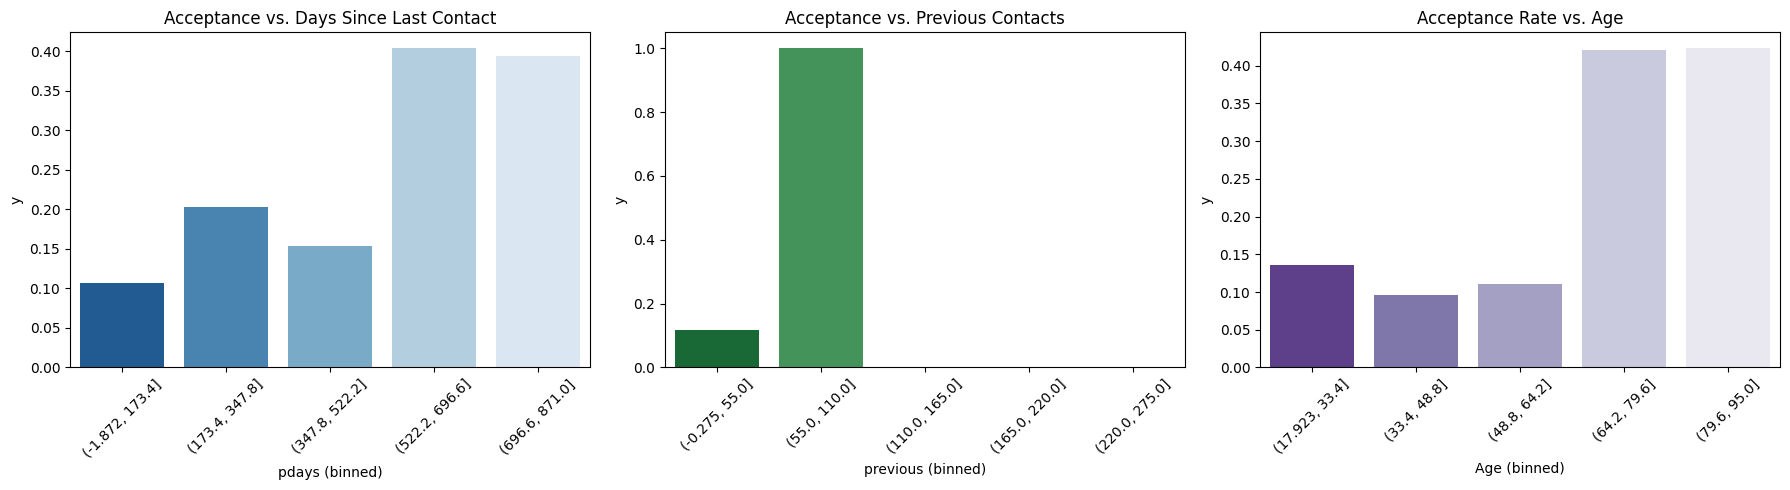

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


# pdays (days since last contact)
df['pdays_bin'] = pd.cut(df['pdays'], bins=5)
pdays_acc = df.groupby('pdays_bin')['y'].mean().reset_index()

sns.barplot(ax=axes[0], x=pdays_acc['pdays_bin'].astype(str), y=pdays_acc['y'], palette="Blues_r")
axes[0].set_title("Acceptance vs. Days Since Last Contact")
axes[0].set_xlabel("pdays (binned)")
axes[0].tick_params(axis='x', rotation=45)

# previous (number of contacts before this campaign)
df['prev_bin'] = pd.cut(df['previous'], bins=5)
prev_acc = df.groupby('prev_bin')['y'].mean().reset_index()

sns.barplot(ax=axes[1], x=prev_acc['prev_bin'].astype(str), y=prev_acc['y'], palette="Greens_r")
axes[1].set_title("Acceptance vs. Previous Contacts")
axes[1].set_xlabel("previous (binned)")
axes[1].tick_params(axis='x', rotation=45)

# age
df['age_bin'] = pd.cut(df['age'], bins=5)
age_acc = df.groupby('age_bin')['y'].mean().reset_index()

sns.barplot(ax=axes[2], x=age_acc['age_bin'].astype(str), y=age_acc['y'], palette="Purples_r")
axes[2].set_title("Acceptance Rate vs. Age")
axes[2].set_xlabel("Age (binned)")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

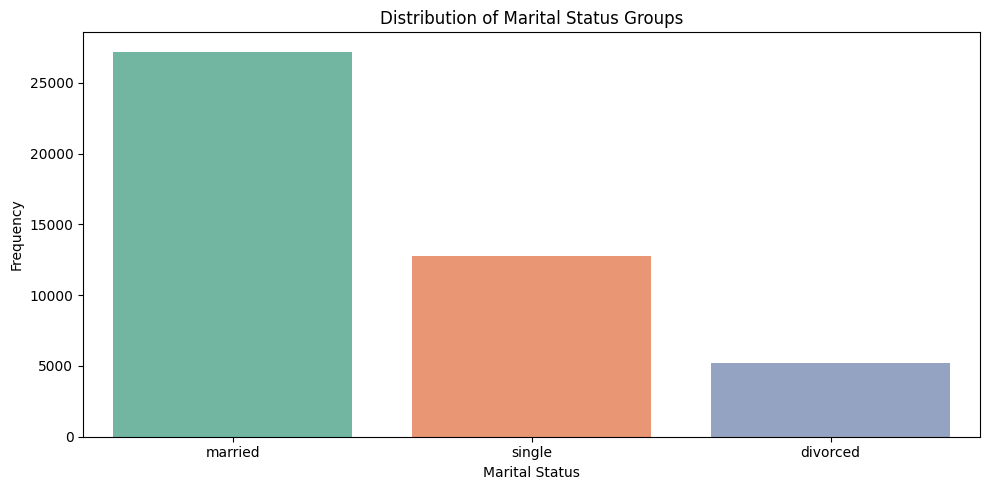

marital_group
married     27214
single      12790
divorced     5207
Name: count, dtype: int64


In [ ]:
# Identify existing marital columns created by get_dummies
marital_cols = [col for col in df.columns if col.startswith('marital_')]

# Reconstruct 'marital_group'. Since drop_first=True was used,
# the category where all dummies are 0 is the dropped one ('divorced').
def get_marital_status(row):
    for col in marital_cols:
        if row[col] == 1:
            return col.replace('marital_', '')
    return 'divorced'

df['marital_group'] = df.apply(get_marital_status, axis=1)

# Plot the distribution of marital status
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='marital_group', palette='Set2')
plt.title("Distribution of Marital Status Groups")
plt.xlabel("Marital Status")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Check count for verification
print(df['marital_group'].value_counts())

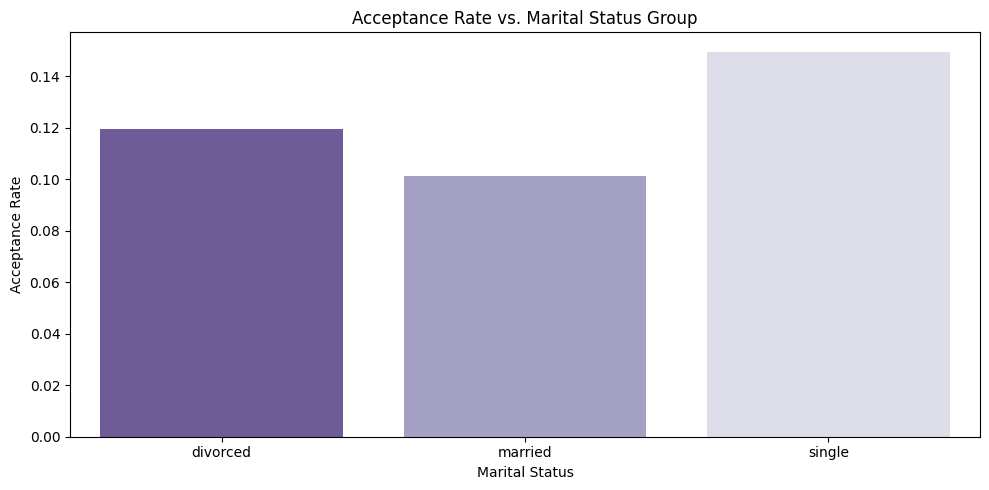

y                  0     1
marital_group             
divorced        4585   622
married        24459  2755
single         10878  1912


In [ ]:
# Compute the acceptance rate for each marital group
marital_acceptance = df.groupby('marital_group').agg(
    y_acceptance=('y', 'mean'),
    count=('y', 'size')
).reset_index()

# Calculate the weighted acceptance rate for each marital group
marital_acceptance['weighted_rate'] = marital_acceptance['y_acceptance'] * marital_acceptance['count'] / marital_acceptance['count'].sum()

# Plot the acceptance rate for Marital Status
plt.figure(figsize=(10, 5))
sns.barplot(x=marital_acceptance['marital_group'], y=marital_acceptance['y_acceptance'], palette="Purples_r")
plt.title("Acceptance Rate vs. Marital Status Group")
plt.xlabel("Marital Status")
plt.ylabel("Acceptance Rate")
plt.tight_layout()
plt.show()

# Check the count of 'Yes' and 'No' responses in each marital group
marital_acceptance_details = df.groupby('marital_group')['y'].value_counts().unstack(fill_value=0)
print(marital_acceptance_details)

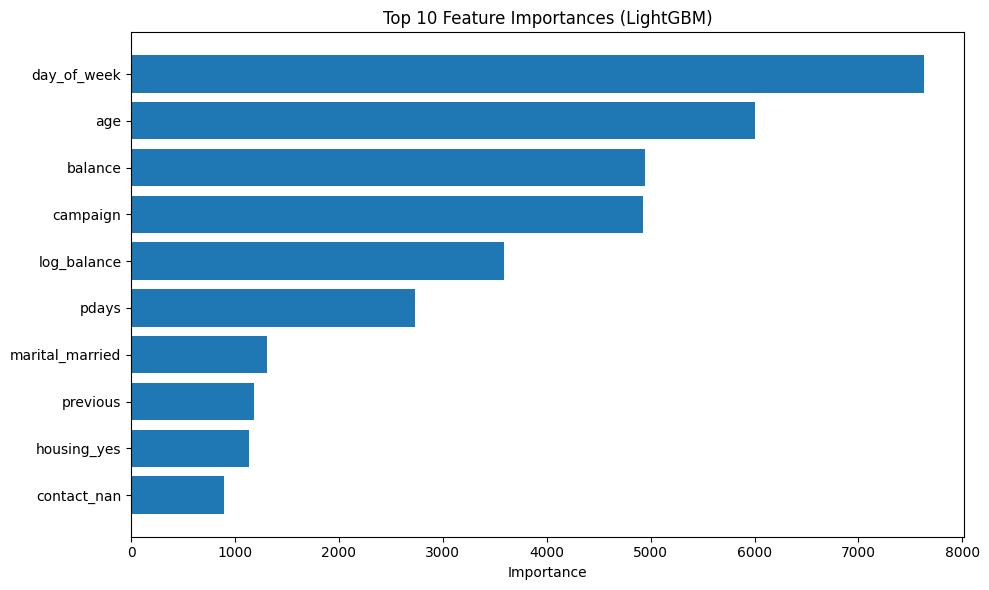

In [ ]:
# Get the trained LightGBM model from the pipeline
lgb_model_pipeline = pipes["LightGBM"]
lgb_model_pipeline.fit(X_train, y_train)
lgb_model = lgb_model_pipeline.named_steps["model"]

# Feature importances
importances = lgb_model.feature_importances_

# Feature names from training data
feature_names = X_train.columns

df_imp = (pd.DataFrame({"Feature": feature_names, "Importance": importances})
          .sort_values("Importance", ascending=False)
          .head(10))

plt.figure(figsize=(10,6))
plt.barh(df_imp["Feature"][::-1], df_imp["Importance"][::-1])
plt.title("Top 10 Feature Importances (LightGBM)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## **8. SHAP Analysis (LightGBM)**
We use SHAP (SHapley Additive exPlanations) to see not just which features are important, but how they influence the prediction negatively or positively.

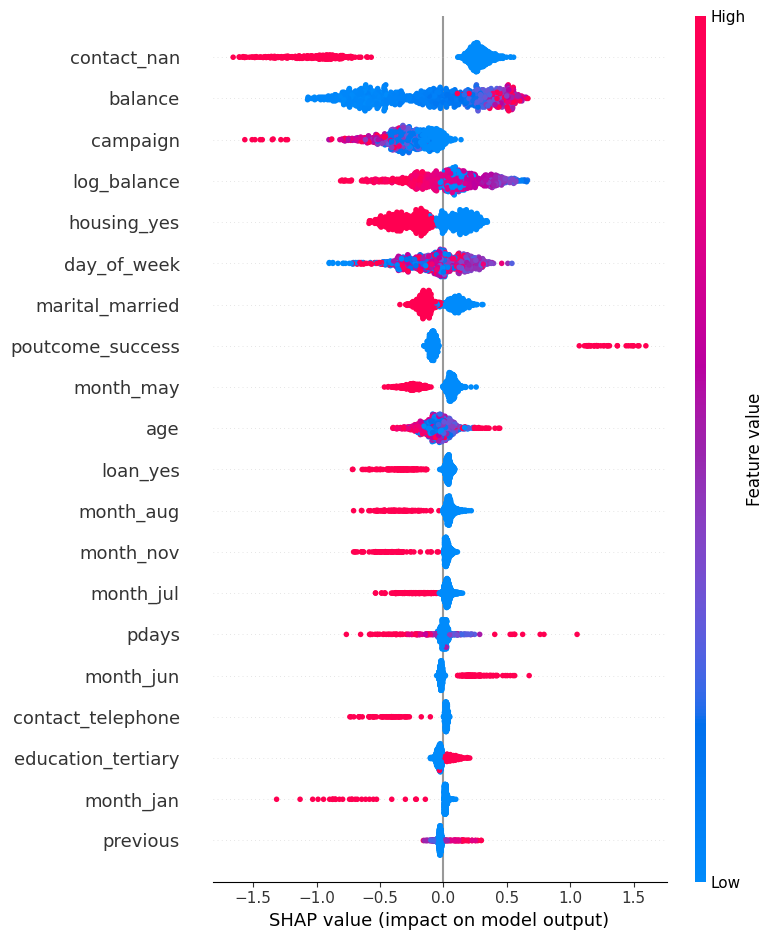

In [ ]:
# Get the trained LightGBM model from the pipeline
lgb_pipe = pipes["LightGBM"]
lgb_model = lgb_pipe.named_steps["model"]

# Sample 1000 rows for faster SHAP computation
X_test_sample = X_test.sample(n=1000, random_state=42)

# Transform using the pipeline's scaler
X_test_scaled_df = pd.DataFrame(
    lgb_pipe.named_steps["scaler"].transform(X_test_sample),
    columns=X_test.columns
)

# Initialize SHAP Explainer
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test_scaled_df)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled_df, plot_type="dot")

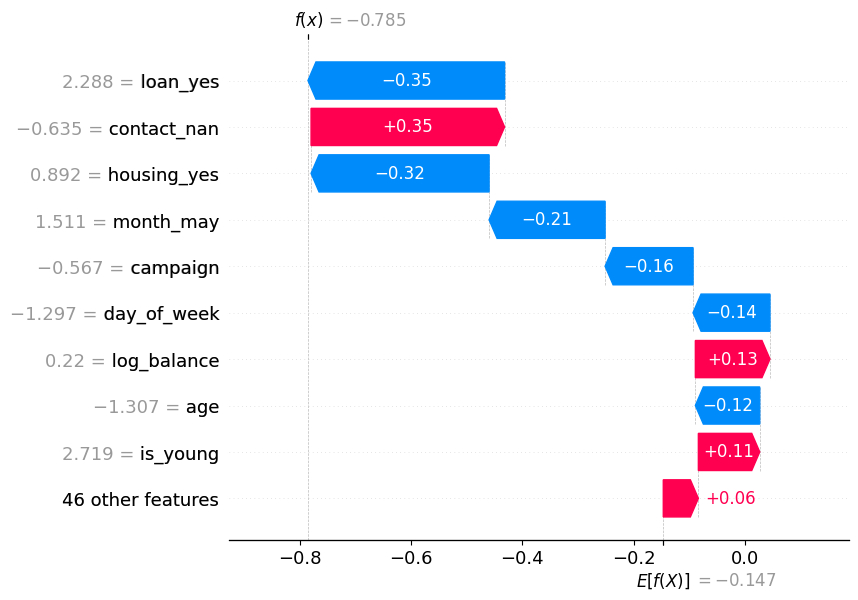

In [ ]:
explainer_obj = explainer(X_test_scaled_df)

plt.figure(figsize=(10, 6))
# Display the waterfall plot for the first sample (index 0)
shap.plots.waterfall(explainer_obj[0])

E(f(X)) stands for the Base Point

f(x) stands for the Model Prediction.

Actual Prediction = Average Prediction + (Sum of all Feature Impacts)

## **9. Predictions & Practical Application**
Finally, we look at specific examples of model predictions and provide a simulator for testing custom client profiles.

In [ ]:
# Calculate overall acceptance rate
# Proportion of "yes" responses in the test set
acceptance_rate = y_test.mean()

print(f"Overall Acceptance Rate: {acceptance_rate:.4%}")  # Display as a percentage

Overall Acceptance Rate: 11.7001%


In [ ]:
# Make predictions and get probabilities with the best model using pipelines for consistency

y_pred_proba = pipes[best_model_name].predict_proba(X_test)[:, 1]
y_pred = pipes[best_model_name].predict(X_test)

# Find correct classifications
correct_indices = np.where(y_pred == y_test.to_numpy())[0]

print(f"Total Correct Classifications: {len(correct_indices)}")
print(f"Out of total test samples: {len(y_test)}\n")

# Display a few examples
print("Example Correct Predictions:")
for i in correct_indices[:5]:
    print(f"Index: {y_test.index[i]} | Actual: {y_test.iloc[i]} | Predicted: {y_pred[i]} | Prob: {y_pred_proba[i]:.4f}")

# Find incorrect classifications
incorrect_indices = np.where(y_pred != y_test.to_numpy())[0]

print(f"\nTotal Incorrect Classifications: {len(incorrect_indices)}")
print(f"Out of total test samples: {len(y_test)}\n")

print("Example Incorrect Predictions (Model errors):")
for i in incorrect_indices[:5]:
    actual = y_test.iloc[i]
    pred = y_pred[i]
    prob = y_pred_proba[i]
    print(f"Index: {y_test.index[i]} | Actual: {actual} | Predicted: {pred} | Prob: {prob:.4f}")

Total Correct Classifications: 11711
Out of total test samples: 13564

Example Correct Predictions:
Index: 37735 | Actual: 1 | Predicted: 1 | Prob: 0.6360
Index: 4432 | Actual: 0 | Predicted: 0 | Prob: 0.1248
Index: 38581 | Actual: 0 | Predicted: 0 | Prob: 0.2566
Index: 33700 | Actual: 1 | Predicted: 1 | Prob: 0.8062
Index: 7859 | Actual: 0 | Predicted: 0 | Prob: 0.2118

Total Incorrect Classifications: 1853
Out of total test samples: 13564

Example Incorrect Predictions (Model errors):
Index: 44332 | Actual: 1 | Predicted: 0 | Prob: 0.4802
Index: 38725 | Actual: 1 | Predicted: 0 | Prob: 0.1213
Index: 33945 | Actual: 0 | Predicted: 1 | Prob: 0.5855
Index: 43340 | Actual: 0 | Predicted: 1 | Prob: 0.9148
Index: 41685 | Actual: 0 | Predicted: 1 | Prob: 0.5211
